In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged dataset
df = pd.read_csv('../data/merged_stock_news.csv')

# Basic info
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   headline      228 non-null    object 
 1   publisher     228 non-null    object 
 2   date          228 non-null    object 
 3   stock         228 non-null    object 
 4   Open          228 non-null    float64
 5   High          228 non-null    float64
 6   Low           228 non-null    float64
 7   Close         228 non-null    float64
 8   Adj Close     228 non-null    float64
 9   Volume        228 non-null    int64  
 10  Dividends     228 non-null    float64
 11  Stock Splits  228 non-null    float64
dtypes: float64(7), int64(1), object(4)
memory usage: 21.5+ KB
None
                                            headline    publisher        date  \
0  MSFT faces regulatory challenges after latest ...          WSJ  2024-06-26   
1                   TSLA stock hits new 6-month high  MarketWat

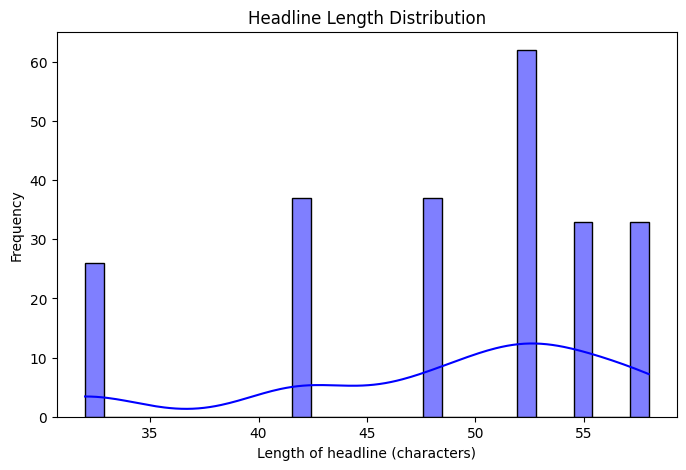

In [2]:
# Add headline length
df['headline_length'] = df['headline'].apply(len)

# Distribution of headline lengths
plt.figure(figsize=(8,5))
sns.histplot(df['headline_length'], bins=30, kde=True, color='blue')
plt.title('Headline Length Distribution')
plt.xlabel('Length of headline (characters)')
plt.ylabel('Frequency')
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_15248\1309386821.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_counts.index, y=publisher_counts.values, palette='viridis')


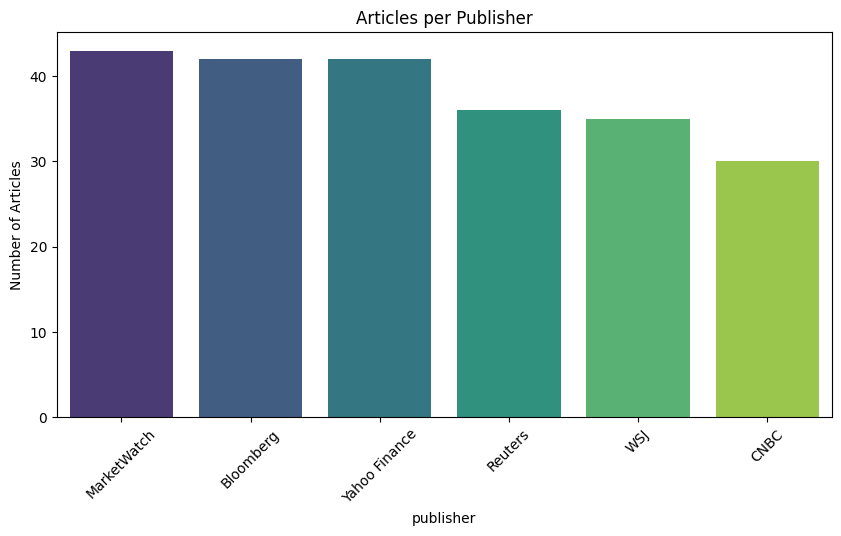

In [3]:
plt.figure(figsize=(10,5))
publisher_counts = df['publisher'].value_counts()
sns.barplot(x=publisher_counts.index, y=publisher_counts.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Articles per Publisher')
plt.ylabel('Number of Articles')
plt.show()


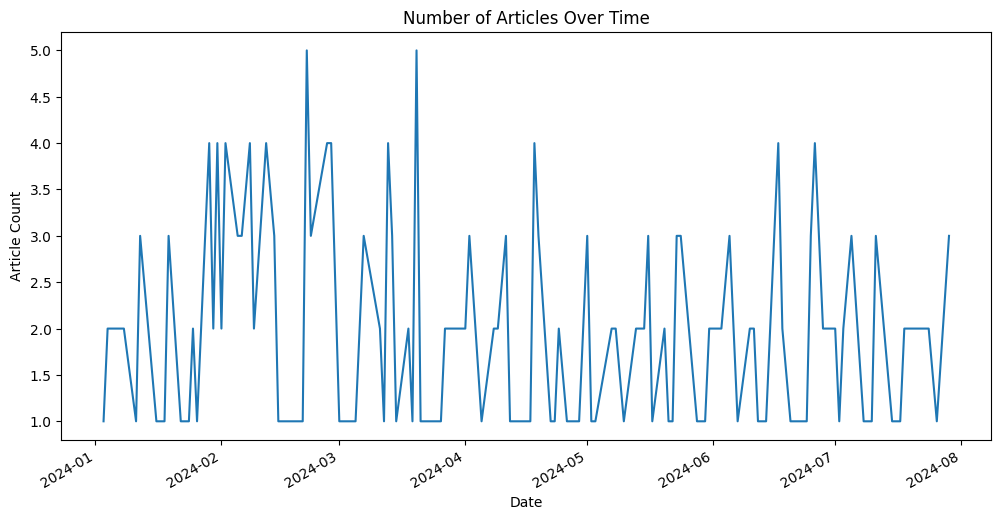

In [4]:
df['date'] = pd.to_datetime(df['date'])
daily_counts = df.groupby('date').size()

plt.figure(figsize=(12,6))
daily_counts.plot()
plt.title('Number of Articles Over Time')
plt.xlabel('Date')
plt.ylabel('Article Count')
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_15248\3091227234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stock_counts.index, y=stock_counts.values, palette='mako')


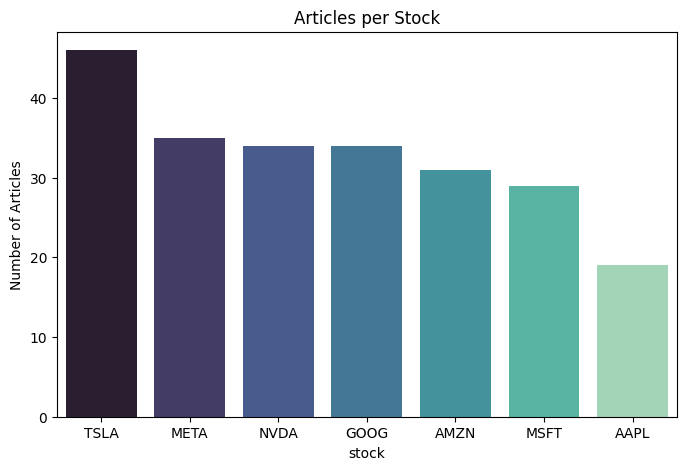

In [5]:
plt.figure(figsize=(8,5))
stock_counts = df['stock'].value_counts()
sns.barplot(x=stock_counts.index, y=stock_counts.values, palette='mako')
plt.title('Articles per Stock')
plt.ylabel('Number of Articles')
plt.show()


In [6]:
from collections import Counter
import re

# Simple word cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    return text

df['clean_headline'] = df['headline'].apply(clean_text)

# Get most common words
all_words = ' '.join(df['clean_headline']).split()
word_freq = Counter(all_words)

# Top 20 keywords
common_words = word_freq.most_common(20)
print(common_words)


[('faces', 70), ('after', 70), ('amid', 70), ('new', 63), ('tsla', 46), ('shares', 37), ('surge', 37), ('product', 37), ('reveal', 37), ('market', 37), ('volatility', 37), ('sector', 37), ('changes', 37), ('meta', 35), ('nvda', 34), ('goog', 34), ('regulatory', 33), ('challenges', 33), ('latest', 33), ('announcement', 33)]


In [5]:
from textblob import TextBlob

# Compute sentiment polarity (-1 = negative, 0 = neutral, +1 = positive)
df['sentiment'] = df['headline'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

# Check if it worked
print(df[['headline', 'sentiment']].head())


                                            headline  sentiment
0  MSFT faces regulatory challenges after latest ...   0.500000
1                   TSLA stock hits new 6-month high   0.148182
2         NVDA shares surge after new product reveal   0.136364
3         AAPL shares surge after new product reveal   0.136364
4   META faces market volatility amid sector changes   0.000000


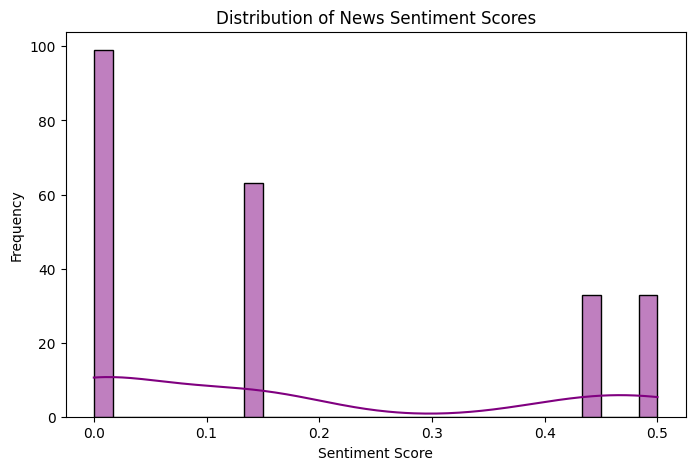

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['sentiment'], bins=30, kde=True, color='purple')
plt.title('Distribution of News Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()


In [7]:
# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Aggregate: daily average sentiment per stock
daily_sentiment = (
    df.groupby(['stock', 'date'])['sentiment']
    .mean()
    .reset_index()
    .rename(columns={'sentiment': 'daily_sentiment'})
)

print(daily_sentiment.head())


  stock       date  daily_sentiment
0  AAPL 2024-01-12         0.000000
1  AAPL 2024-01-31         0.000000
2  AAPL 2024-02-02         0.433333
3  AAPL 2024-02-12         0.000000
4  AAPL 2024-03-15         0.433333
